In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("heart_ex.csv")

In [161]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    str    
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(12), str(1)
memory usage: 33.3 KB
None


In [162]:
#vraag 1
cp = df["cp"]
cp_counts = cp.value_counts()
print(cp_counts)

cp
typical angina      143
non-anginal pain     87
atypical angina      50
asymptomatic         23
Name: count, dtype: int64


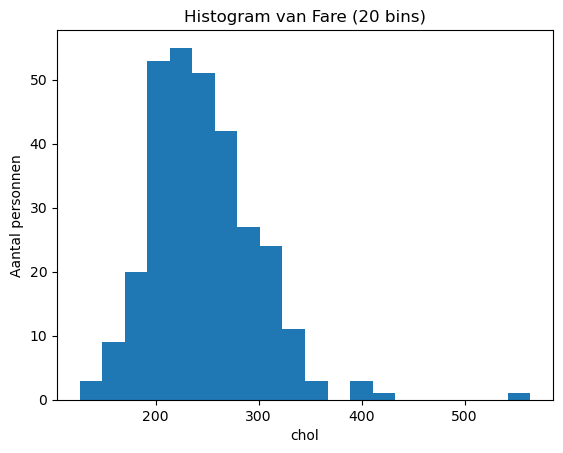

In [163]:
#vraag 2
chol = df["chol"]
chol.plot.hist(bins=20)
plt.xlabel("chol")
plt.ylabel("Aantal personnen")
plt.title("Histogram van Fare (20 bins)")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

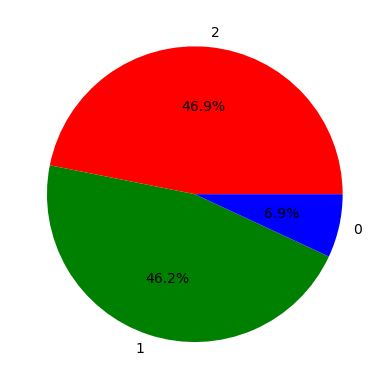

In [164]:
#vraag 3 
slp = df["slp"]
slp.value_counts().plot(kind="pie",autopct="%1.1f%%",colors=["red","green","blue"])
plt.show

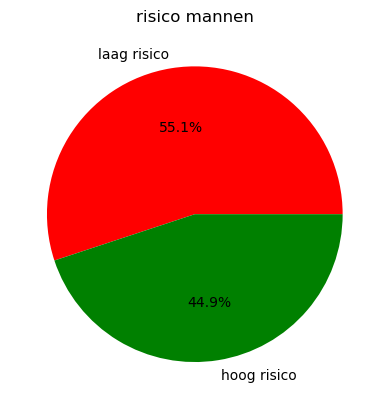

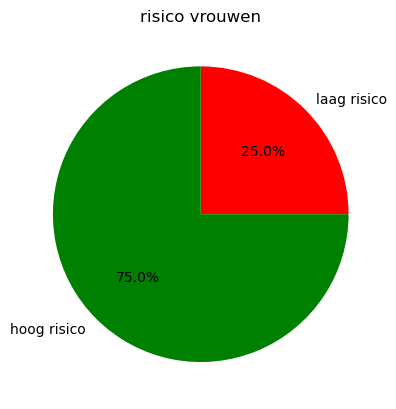

output,0,1
sex,,
0,24,72
1,114,93


In [176]:
#vraag 4 
men = df[df["sex"] == 1]
woman = df[df["sex"] == 0]


men["status"] = men["output"].map({0: "laag risico", 1: "hoog risico"})
men["status"].value_counts().reindex(["laag risico", "hoog risico"]).plot(kind="pie",autopct="%1.1f%%",colors=["red","green"])
plt.title("risico mannen")
plt.show()

woman["status"] = woman["output"].map({0: "laag risico", 1: "hoog risico"})
woman["status"].value_counts().reindex(["laag risico", "hoog risico"]).plot(kind="pie",autopct="%1.1f%%",colors=["red","green"])
plt.title("risico vrouwen")
plt.show()

pd.crosstab(df.sex, df.output)

             chol  thalachh
chol      1.00000  -0.00994
thalachh -0.00994   1.00000


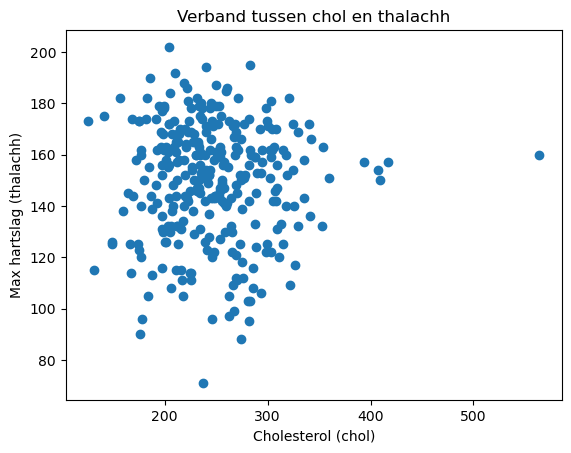

In [166]:
#vraag 5
thalachh = df["thalachh"]
plt.scatter(df["chol"], df["thalachh"])

plt.xlabel("Cholesterol (chol)")
plt.ylabel("Max hartslag (thalachh)")
plt.title("Verband tussen chol en thalachh")

print(df[["chol", "thalachh"]].corr())



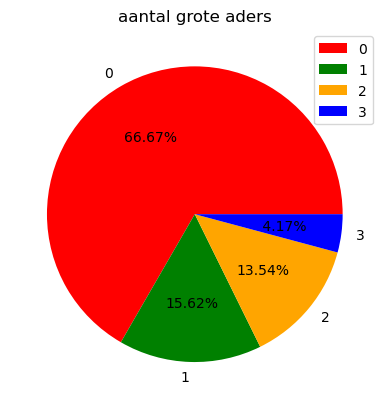

In [167]:
#vraag 6
woman = df[df["sex"] == 0]

woman["status"] = woman["caa"]
woman["status"].value_counts().plot(kind="pie",autopct="%5.2f%%",colors=["red","green","orange","blue","yellow"])
plt.title("aantal grote aders")
plt.legend()
plt.show()

In [168]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

In [169]:
#vraag 7
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
df['cp'] = label_encoder.fit_transform(df['cp'])
print(df.head(5))
heart_ML = df[["age",
               "cp",
                "sex",
                "trtbps",
                "chol",
                "fbs",
                "restecg",
                "exng",
                "caa",
                "oldpeak",
                "slp"]]
y = df['output']
x = heart_ML


   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   0     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   3     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [170]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.33,
    random_state=42
)

In [172]:
from sklearn import tree
from sklearn import metrics

model = tree.DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"{metrics.accuracy_score(y_test, y_pred):.5f}")

0.78000


In [173]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=2)
selector.fit(X_train, y_train)

SelectKBest(k=2, score_func=<function chi2 at 0x7fe72391dda0>)

In [175]:
X_train_new = selector.transform(X_train)
X_test_new = selector.transform(X_test)

# create model
model = tree.DecisionTreeClassifier(random_state=0)

# fit model using selected features
model.fit(X_train_new, y_train)

# predict using selected test features
y_pred = model.predict(X_test_new)

accuracy = metrics.accuracy_score(y_test, y_pred)
print(accuracy)

0.65
